# Визулизация данных

In [1]:
import sklearn
import pandas as pd

In [2]:
df_train = pd.read_csv('data\\train.csv', index_col='id')

In [3]:
df_train.head()

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
id,,,,,,,,,,,,,,,,,,,
1,Aakash,Male,47,Agra,Working Professional,Teacher,NaN,1.0,NaN,NaN,5.0,Less than 5 hours,Unhealthy,B.Arch,Yes,11,5,Yes,0
2,Asha,Female,25,Chennai,Student,NaN,3.0,NaN,6.59,1.0,NaN,7-8 hours,Healthy,BSc,No,9,3,No,0
3,Samar,Male,56,Indore,Working Professional,Data Scientist,NaN,3.0,NaN,NaN,2.0,7-8 hours,Moderate,B.Tech,No,2,4,Yes,0
4,Chhavi,Female,24,Kalyan,Student,NaN,2.0,NaN,5.77,2.0,NaN,5-6 hours,Moderate,MBBS,Yes,5,3,No,1
5,Anand,Male,55,Kanpur,Working Professional,Researcher,NaN,1.0,NaN,NaN,2.0,7-8 hours,Unhealthy,BSc,Yes,4,4,No,0


In [4]:
df_train.shape

(1891, 19)

In [5]:
X = df_train.iloc[:, :-1]
y = df_train.iloc[:, -1]

In [6]:
X

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
id,,,,,,,,,,,,,,,,,,
1,Aakash,Male,47,Agra,Working Professional,Teacher,NaN,1.0,NaN,NaN,5.0,Less than 5 hours,Unhealthy,B.Arch,Yes,11,5,Yes
2,Asha,Female,25,Chennai,Student,NaN,3.0,NaN,6.59,1.0,NaN,7-8 hours,Healthy,BSc,No,9,3,No
3,Samar,Male,56,Indore,Working Professional,Data Scientist,NaN,3.0,NaN,NaN,2.0,7-8 hours,Moderate,B.Tech,No,2,4,Yes
4,Chhavi,Female,24,Kalyan,Student,NaN,2.0,NaN,5.77,2.0,NaN,5-6 hours,Moderate,MBBS,Yes,5,3,No
5,Anand,Male,55,Kanpur,Working Professional,Researcher,NaN,1.0,NaN,NaN,2.0,7-8 hours,Unhealthy,BSc,Yes,4,4,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,Rahil,Male,50,Ahmedabad,Working Professional,Electrician,NaN,4.0,NaN,NaN,3.0,More than 8 hours,Healthy,BSc,Yes,2,5,Yes
1888,Rashi,Female,28,Vasai-Virar,Student,NaN,4.0,NaN,9.10,2.0,NaN,Less than 5 hours,Moderate,Class 12,Yes,11,5,Yes
1889,Barkha,Female,46,Kanpur,Working Professional,Content Writer,NaN,4.0,NaN,NaN,4.0,More than 8 hours,Unhealthy,BE,No,5,5,No


In [7]:
nan_df = (X.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
9,Study Satisfaction,79.799048
8,CGPA,79.799048
6,Academic Pressure,79.799048
5,Profession,27.022739
7,Work Pressure,20.200952
10,Job Satisfaction,20.200952
1,Gender,0.000000
0,Name,0.000000
2,Age,0.000000
4,Working Professional or Student,0.000000


Видим, что пропуски только в 6 колонках датасета

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

выведем матрицу диаграм рассеянея

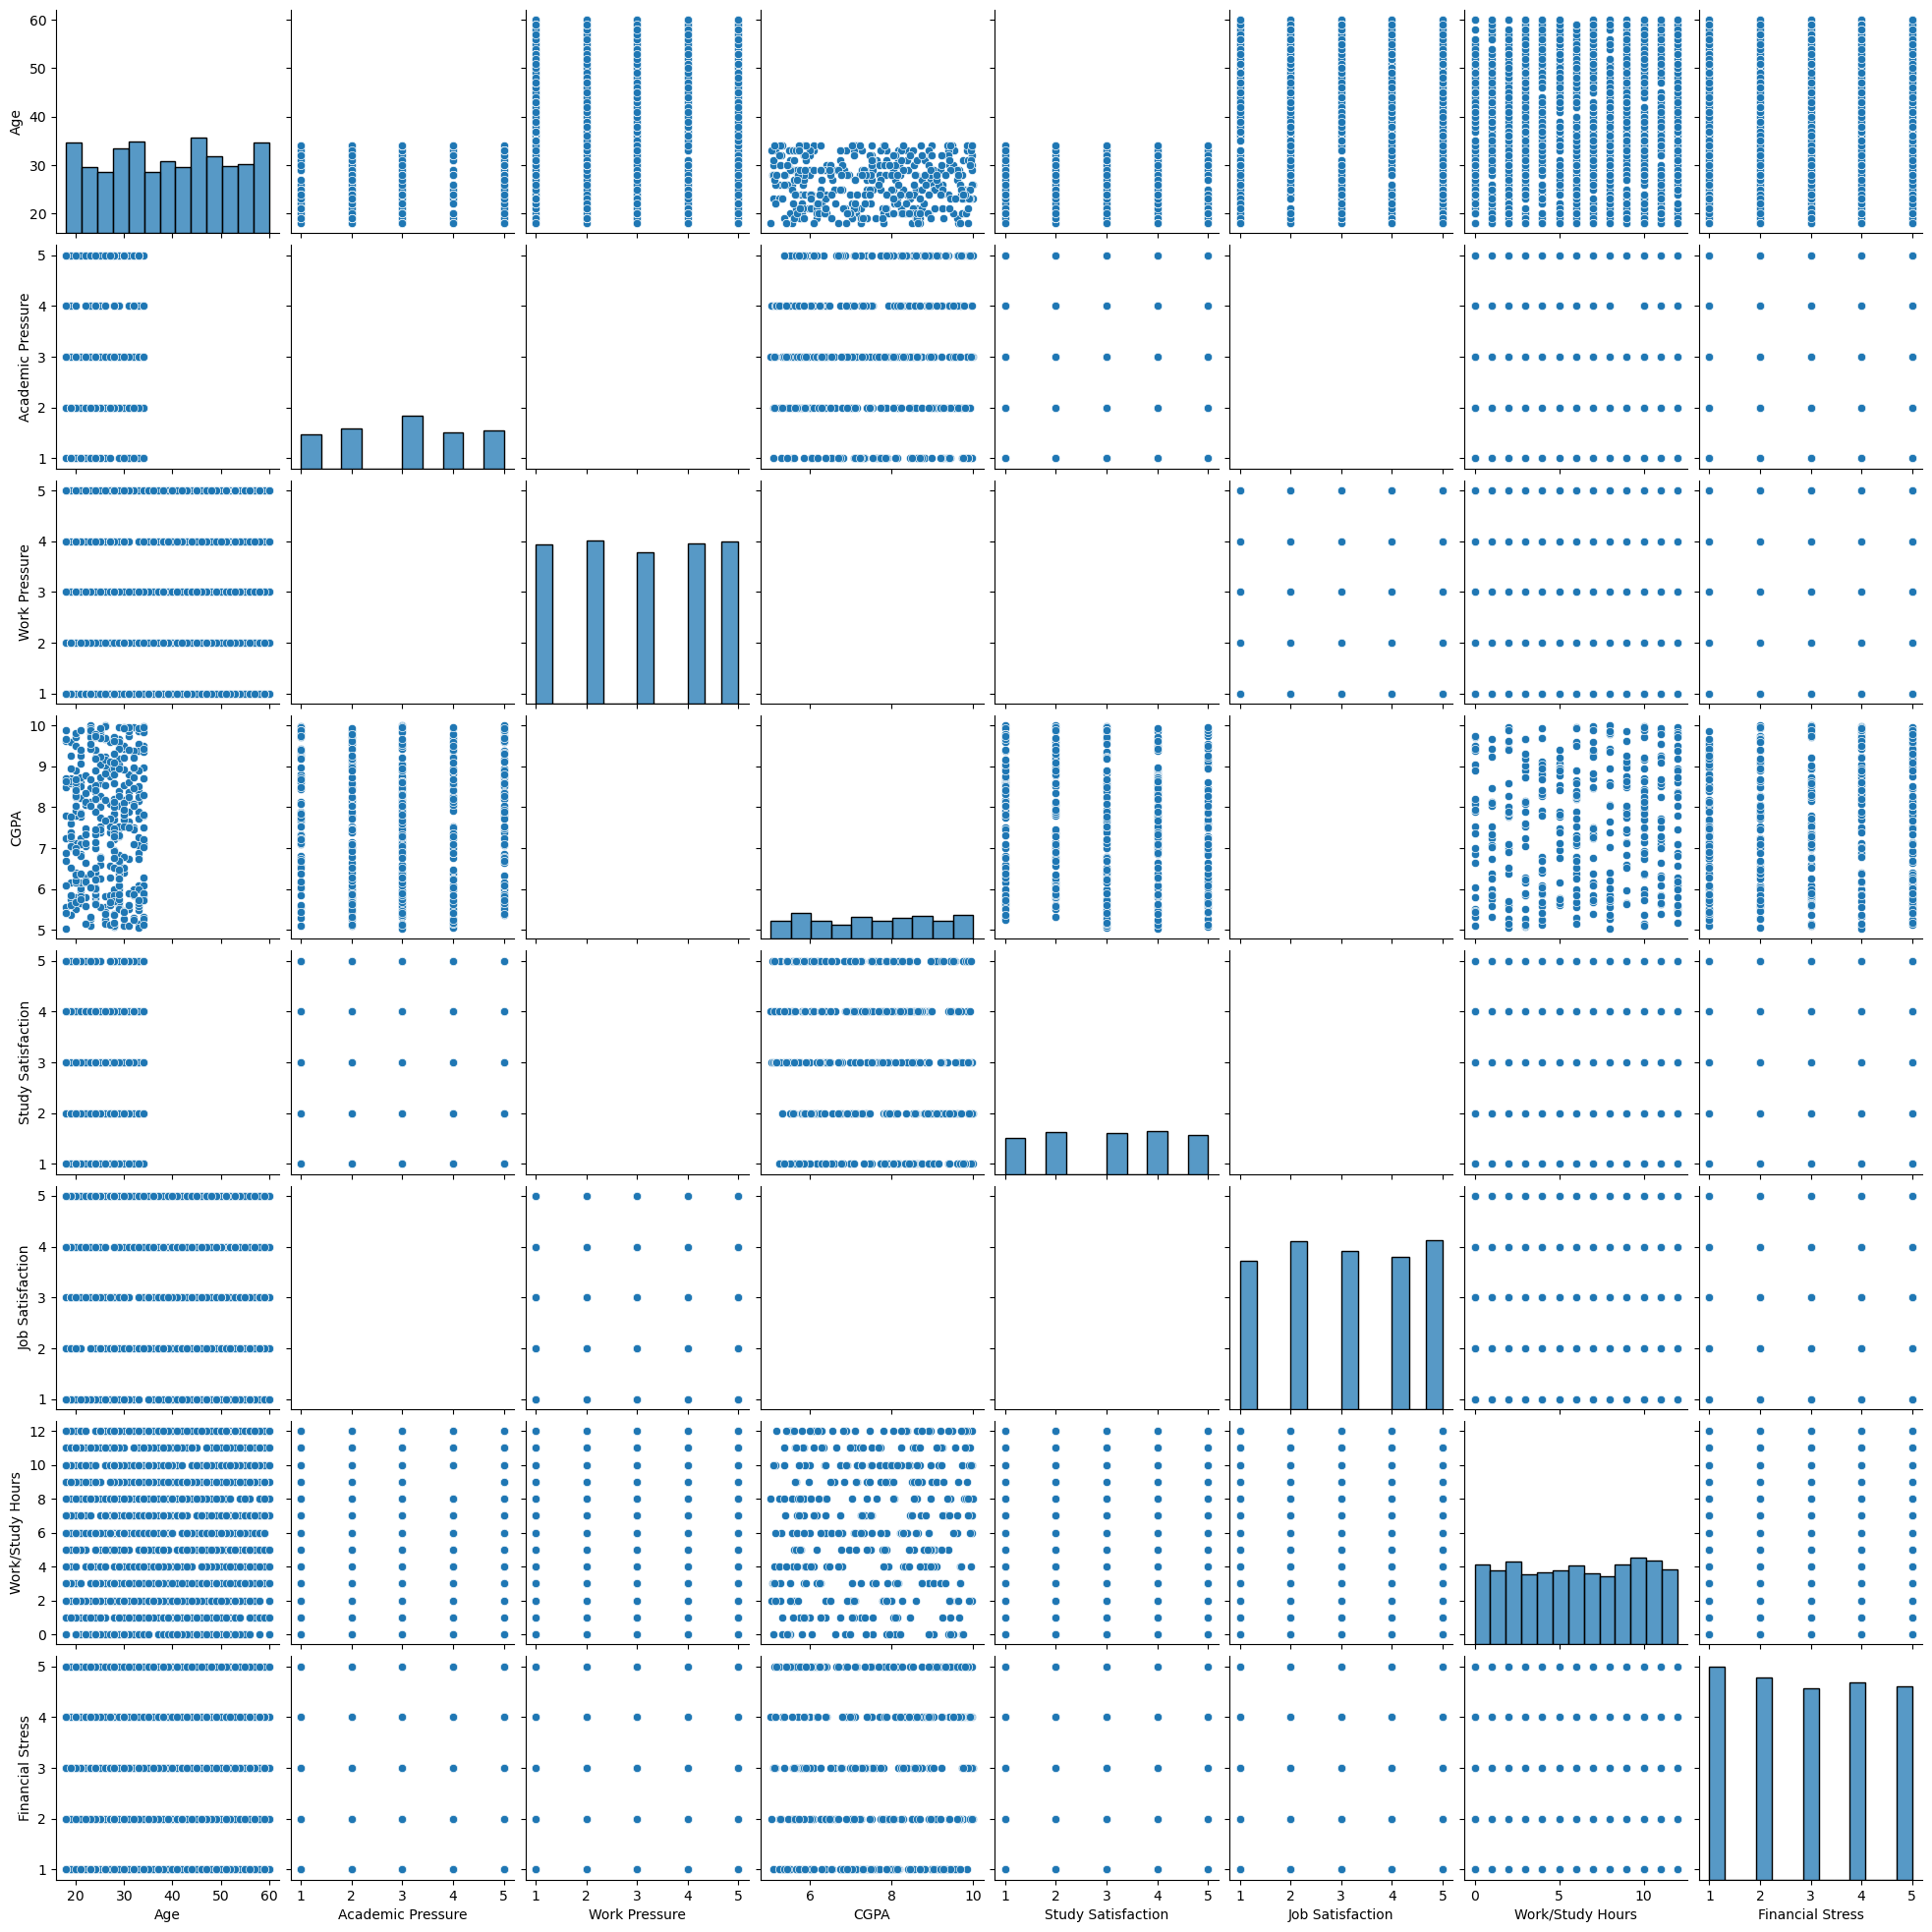

In [9]:
sns.pairplot(X)

Проверим, что некоторые значения имеют одинаковый смысл и не дублируются в одной строке

In [10]:
X[['Job Satisfaction', 'Study Satisfaction']].notna().all(axis=1).sum()

np.int64(0)

In [11]:
X[['Academic Pressure', 'Work Pressure']].notna().all(axis=1).sum()

np.int64(0)

Значит можно объеденить столбцы

In [12]:
X['job/study satisfaction'] = X['Job Satisfaction'].fillna(X['Study Satisfaction'])

In [13]:
X['Work/Academic Pressure'] = X['Academic Pressure'].fillna(X['Work Pressure'])

In [14]:
X.drop(columns=['Job Satisfaction', 'Study Satisfaction', 'Academic Pressure', 'Work Pressure'], inplace=True)

In [15]:
X['Profession'].unique()

<StringArray>
[               'Teacher',                      nan,         'Data Scientist',
             'Researcher',         'Civil Engineer',             'HR Manager',
       'Business Analyst',         'Content Writer',                'Manager',
                 'Lawyer',      'Travel Consultant',       'Digital Marketer',
            'Electrician',             'Accountant',             'Consultant',
                'Chemist',                  'Pilot',    'Mechanical Engineer',
      'Marketing Manager',       'Research Analyst',                'Plumber',
             'Pharmacist',              'Architect',                   'Chef',
                 'Doctor', 'Educational Consultant',         'UX/UI Designer',
    'Finanancial Analyst',        'Sales Executive',                  'Judge',
      'Financial Analyst',           'Entrepreneur',      'Software Engineer',
       'Customer Support',       'Graphic Designer',      'Investment Banker']
Length: 36, dtype: str

In [16]:
X.fillna({'Profession': 'unemployed'}, inplace=True)

,Name,Gender,Age,City,Working Professional or Student,Profession,CGPA,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,job/study satisfaction,Work/Academic Pressure
id,,,,,,,,,,,,,,,,
1,Aakash,Male,47,Agra,Working Professional,Teacher,NaN,Less than 5 hours,Unhealthy,B.Arch,Yes,11,5,Yes,5.0,1.0
2,Asha,Female,25,Chennai,Student,unemployed,6.59,7-8 hours,Healthy,BSc,No,9,3,No,1.0,3.0
3,Samar,Male,56,Indore,Working Professional,Data Scientist,NaN,7-8 hours,Moderate,B.Tech,No,2,4,Yes,2.0,3.0
4,Chhavi,Female,24,Kalyan,Student,unemployed,5.77,5-6 hours,Moderate,MBBS,Yes,5,3,No,2.0,2.0
5,Anand,Male,55,Kanpur,Working Professional,Researcher,NaN,7-8 hours,Unhealthy,BSc,Yes,4,4,No,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,Rahil,Male,50,Ahmedabad,Working Professional,Electrician,NaN,More than 8 hours,Healthy,BSc,Yes,2,5,Yes,3.0,4.0
1888,Rashi,Female,28,Vasai-Virar,Student,unemployed,9.10,Less than 5 hours,Moderate,Class 12,Yes,11,5,Yes,2.0,4.0
1889,Barkha,Female,46,Kanpur,Working Professional,Content Writer,NaN,More than 8 hours,Unhealthy,BE,No,5,5,No,4.0,4.0


Исключим колонку CGPA, так как в ней слишком много пропусков

In [17]:
X.drop('CGPA', inplace=True, axis=1)
X

,Name,Gender,Age,City,Working Professional or Student,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,job/study satisfaction,Work/Academic Pressure
id,,,,,,,,,,,,,,,
1,Aakash,Male,47,Agra,Working Professional,Teacher,Less than 5 hours,Unhealthy,B.Arch,Yes,11,5,Yes,5.0,1.0
2,Asha,Female,25,Chennai,Student,unemployed,7-8 hours,Healthy,BSc,No,9,3,No,1.0,3.0
3,Samar,Male,56,Indore,Working Professional,Data Scientist,7-8 hours,Moderate,B.Tech,No,2,4,Yes,2.0,3.0
4,Chhavi,Female,24,Kalyan,Student,unemployed,5-6 hours,Moderate,MBBS,Yes,5,3,No,2.0,2.0
5,Anand,Male,55,Kanpur,Working Professional,Researcher,7-8 hours,Unhealthy,BSc,Yes,4,4,No,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,Rahil,Male,50,Ahmedabad,Working Professional,Electrician,More than 8 hours,Healthy,BSc,Yes,2,5,Yes,3.0,4.0
1888,Rashi,Female,28,Vasai-Virar,Student,unemployed,Less than 5 hours,Moderate,Class 12,Yes,11,5,Yes,2.0,4.0
1889,Barkha,Female,46,Kanpur,Working Professional,Content Writer,More than 8 hours,Unhealthy,BE,No,5,5,No,4.0,4.0
